In [1]:
# IMPORT LIBRARIES AND CONFIGURE PATHS
# Core scientific computing libraries for data analysis
import numpy as np          # Numerical operations and array handling
import scipy as sc          # Scientific computing functions (filtering, etc.)
import pandas as pd         # Data manipulation and analysis

# Visualization library
import matplotlib.pyplot as plt  # Plotting and figure generation

# System and file handling utilities
from os.path import join as ospj  # Cross-platform path joining
from utils import *               # Custom utility functions

# Load configuration paths and settings
from config import Config
# Extract key paths: raw data, processed data, metadata, figures, and patient IDs
datapath, prodatapath, metapath, figpath, rid_hup = Config.deal(['datapath','prodatapath','metapath','figpath','rid_hup'])

## NDD heritage

In [2]:
ndd_old = pd.read_csv(ospj(prodatapath,'res_series_list_ndd.csv'))

<Axes: xlabel='hidden_size', ylabel='test_r2'>

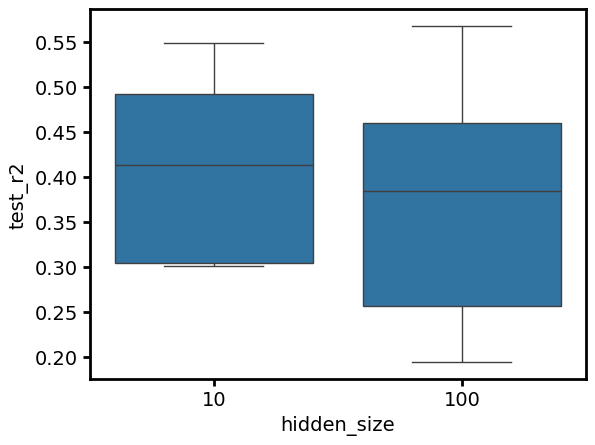

In [3]:
sns.boxplot(ndd_old[ndd_old['duration']==60],x='hidden_size',y='test_r2')

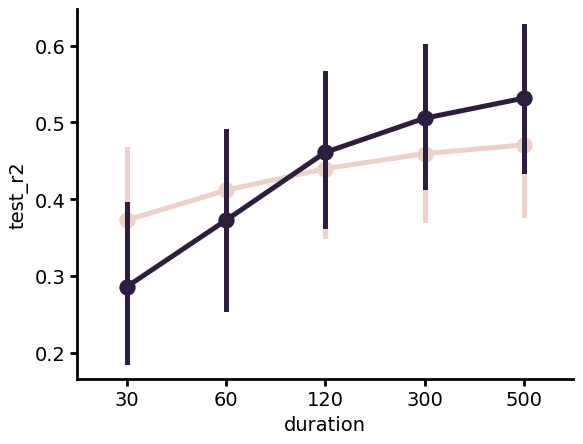

In [4]:
sns.pointplot(x='duration',hue='hidden_size',y='test_r2',data=ndd_old[ndd_old['forecast_length']==1],legend=False)
sns.despine()

## MINDD hyperparameter optimization

In [5]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP276')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.2,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2   hidden_sizes     weights  sequence_length
838  0.846805  0.965526  0.903373  [23808, 3571]    (2, 0.3)              128
363  0.845000  0.958604  0.898688         [9523]      (0.8,)              128
350  0.841300  0.963947  0.899778   [9523, 3571]  (0.8, 0.3)              128
482  0.838377  0.955403  0.894399  [23808, 5952]    (2, 0.5)              128
146  0.836983  0.947585  0.888647         [5952]        (1,)               64
686  0.836541  0.951603  0.890698         [5952]      (0.5,)              128
274  0.826928  0.943451  0.882598        [11904]        (1,)              128
644  0.825952  0.941971  0.880302         [3571]      (0.3,)              128
411  0.824927  0.933344  0.875037         [4761]      (0.8,)               64
259  0.814732  0.938007  0.873368   [5952, 5952]  (0.5, 0.5)              128
816  0.814342  0.937076  0.872548   [5952, 9523]  (0.5, 0.8)              128
545  0.814245  0.933374  0.871234  [11904, 5952]    (1, 0.5)    

In [6]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP065')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.3,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2  hidden_sizes     weights  sequence_length
534  0.858744  0.902651  0.894761   [2816, 422]    (2, 0.3)              128
788  0.840073  0.860177  0.874863   [2816, 704]    (2, 0.5)              128
844  0.831381  0.816321  0.866048  [1126, 2816]    (0.8, 2)              128
23   0.828822  0.808358  0.860316  [1126, 1126]  (0.8, 0.8)              128
20   0.828103  0.803983  0.860048  [1126, 1408]    (0.8, 1)              128
228  0.824571  0.816775  0.857192  [2816, 1126]    (2, 0.8)              128
746  0.817343  0.794082  0.846728   [1126, 422]  (0.8, 0.3)              128
715  0.816621  0.786109  0.847647        [2816]        (2,)              128
603  0.816537  0.782077  0.845812   [1126, 704]  (0.8, 0.5)              128
287  0.812146  0.776206  0.843029  [1408, 1126]    (1, 0.8)              128
208  0.809768  0.755488  0.836746        [1408]        (1,)              128
850  0.804837  0.760632  0.834478   [1408, 704]    (1, 0.5)              128

In [7]:
group_cols = ['sequence_length','weights']
ndd_data_avg = mindd_results.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,weights,train_r2,val_r2,test_r2
0,128,"(2, 0.3)",0.902651,0.894761,0.858744


## NDD System Identification

In [8]:
# ndd_data = pd.read_csv(ospj(prodatapath,'res_series_list_deep.csv'))
# ndd_data['model'] = ndd_data['model'].apply(lambda x: x.split('.')[-1][:-2])

In [9]:
ndd_data = pd.read_csv(ospj(prodatapath,'compiled_ndd_optimization_results.csv'))
# ndd_data = ndd_data[ndd_data['patient']=='HUP065']
gin_data = ndd_data[ndd_data['model']=='GIN']
lin_data = ndd_data[ndd_data['model']=='LiNDDA']
min_data = ndd_data[ndd_data['model']=='MINDD']
lir_data = ndd_data[ndd_data.model=='LiRNDDA']

In [10]:
ndd_data.patient.nunique()

5

<Axes: xlabel='duration', ylabel='test_r2'>

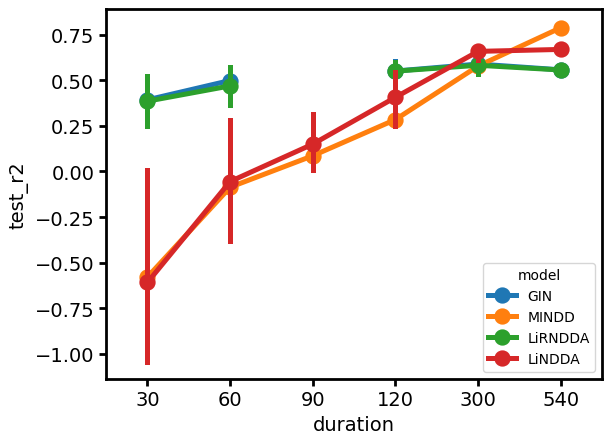

In [11]:
sns.pointplot(x='duration',hue='model',y='test_r2',data=ndd_data[ndd_data['sequence_length']==128])

<Axes: xlabel='sequence_length', ylabel='test_r2'>

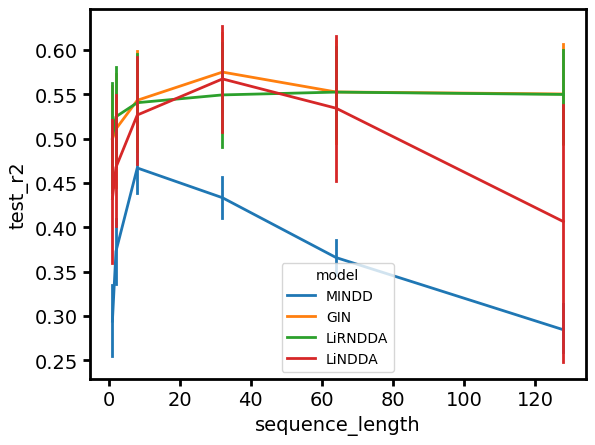

In [12]:
sns.lineplot(x='sequence_length',hue='model',y='test_r2',data=ndd_data[ndd_data['duration']==120],err_style='bars')

In [18]:
group_cols = ['sequence_length','num_layers','num_stacks']
ndd_data_avg = gin_data[gin_data.duration == 120].groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,num_layers,num_stacks,train_r2,val_r2,test_r2
0,32,1.0,1.0,0.455521,0.53808,0.574985


<Axes: xlabel='sequence_length', ylabel='test_r2'>

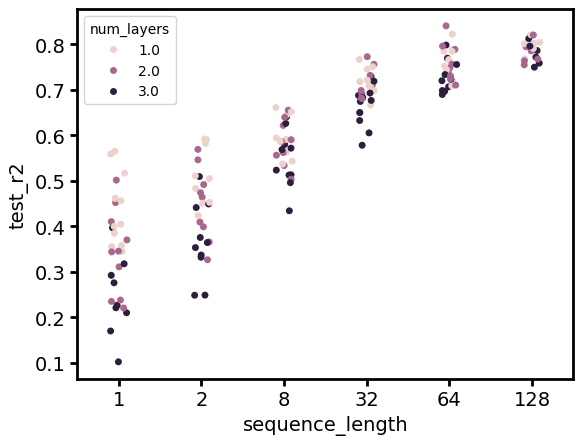

In [30]:
sns.stripplot(x='sequence_length',y='test_r2',hue='num_layers',data=min_data[min_data['duration']==540])

<Axes: xlabel='sequence_length', ylabel='train_s'>

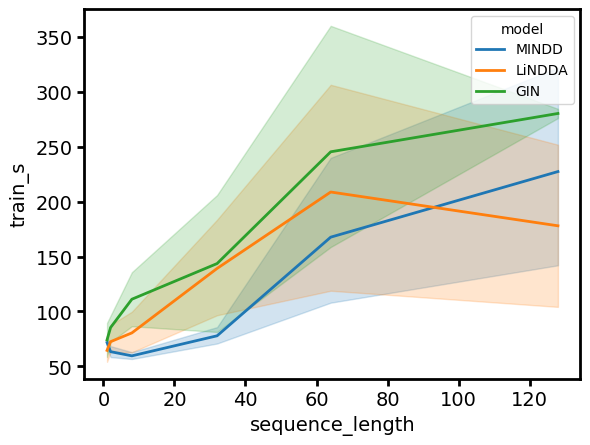

In [31]:
sns.lineplot(x='sequence_length',hue='model',y='train_s',data=ndd_data[(ndd_data['duration']==540)&(ndd_data.model != 'LiRNDDA')])

<Axes: xlabel='sequence_length', ylabel='test_r2'>

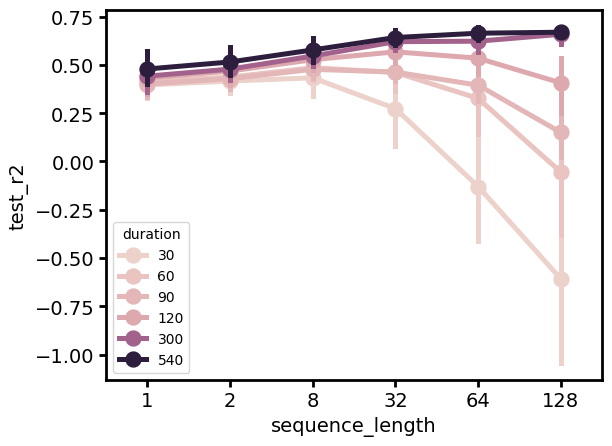

In [32]:
sns.pointplot(lin_data,x='sequence_length',hue='duration',y='test_r2')

(0.0, 1.0)

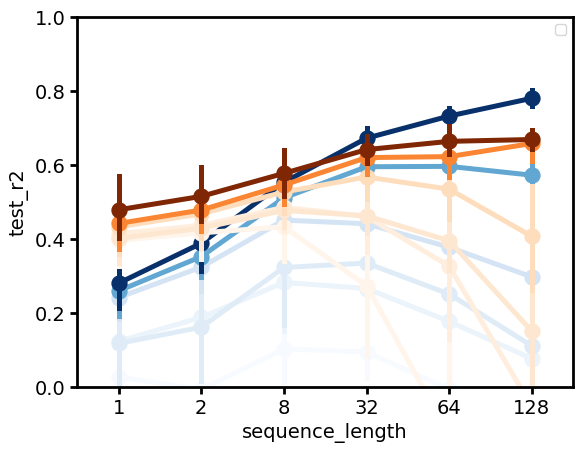

In [33]:
sns.pointplot(min_data[(min_data['param_scale']==1)],x='sequence_length',y='test_r2',hue='duration',palette='Blues')
sns.pointplot(lin_data,x='sequence_length',y='test_r2',hue='duration',palette='Oranges')
plt.legend([])
plt.ylim(0,1)

In [34]:
group_cols = ['model','duration','sequence_length','num_layers','param_scale','num_stacks','forecast_length']
ndd_data_avg = ndd_data.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
for model in ndd_data_avg['model'].unique():
    for duration in ndd_data_avg['duration'].unique():
        subset = ndd_data_avg[(ndd_data_avg['model'] == model) & (ndd_data_avg['duration'] == duration)]
        if subset.empty: continue
        max_r2 = subset['test_r2'].max()
        best = subset[subset['test_r2'] == max_r2]
        best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['model','duration','sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()


,model,duration,sequence_length,num_layers,param_scale,num_stacks,forecast_length,train_r2,val_r2,test_r2
0,GIN,30,64,1.0,NaN,1.0,1,0.378659,0.394394,0.409219
1,GIN,60,32,1.0,NaN,1.0,1,0.434224,0.462267,0.507847
2,GIN,120,32,1.0,NaN,1.0,1,0.455521,0.538080,0.574985
3,GIN,300,128,1.0,NaN,1.0,1,0.469911,0.551114,0.588645
4,GIN,540,32,1.0,NaN,1.0,1,0.471488,0.606583,0.608054
5,LiNDDA,30,8,NaN,NaN,NaN,1,0.434550,0.504924,0.432667
6,LiNDDA,60,8,NaN,NaN,NaN,1,0.431026,0.511783,0.484901
10,LiNDDA,90,8,NaN,NaN,NaN,1,0.425589,0.504898,0.476701
7,LiNDDA,120,32,NaN,NaN,NaN,1,0.527712,0.622853,0.567271
8,LiNDDA,300,128,NaN,NaN,NaN,1,0.630197,0.677594,0.657976


<Axes: xlabel='sequence_length', ylabel='test_r2'>

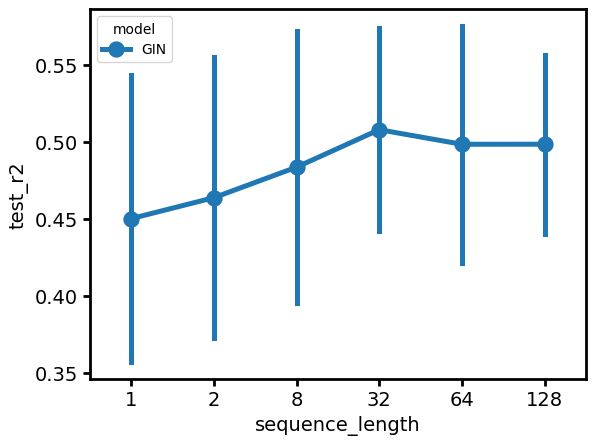

In [35]:
sns.pointplot(x='sequence_length',hue='model',y='test_r2',data=gin_data[(gin_data['duration']==60)])

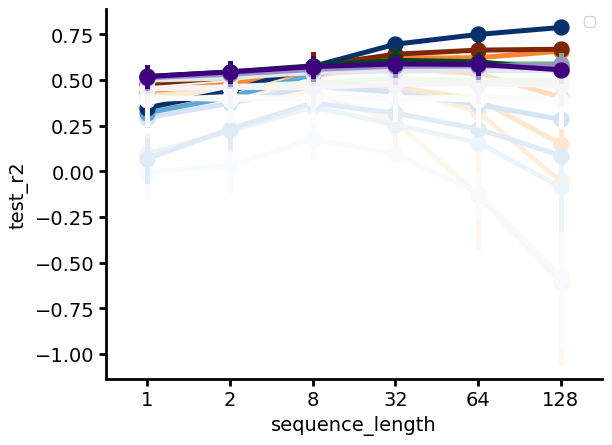

In [36]:
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lin_data[lin_data['forecast_length']==1],palette='Oranges')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=min_data[min_data['forecast_length']==1],palette='Blues')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=gin_data[gin_data['forecast_length']==1],palette='Greens')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lir_data[lir_data['forecast_length']==1],palette='Purples')
plt.legend([])
sns.despine()

<Axes: xlabel='model', ylabel='train_s'>

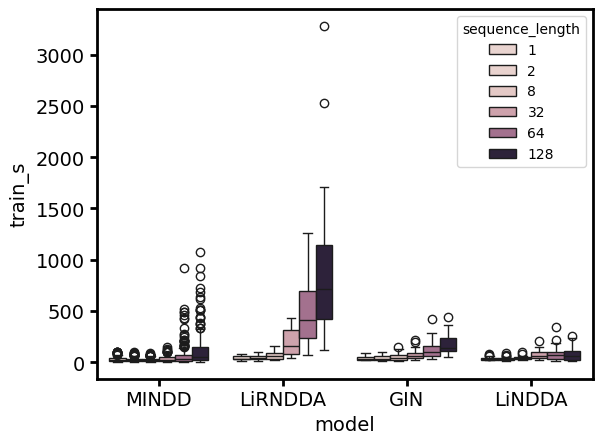

In [37]:
sns.boxplot(x='model',hue='sequence_length',y='train_s',data=ndd_data)

## Validation performance

In [38]:
shallow_data = pd.read_csv(ospj(prodatapath, "benchmark_model_validation_results.csv"))
shallow_melted = pd.melt(shallow_data, id_vars=['model'], value_vars=['auc','iou_f1','iou_phi','iou_sensitivity','iou_specificity','iou_precision','iou_recall','f1_f1','f1_phi','f1_sensitivity','f1_specificity','f1_precision','f1_recall'], var_name='metric', value_name='value')

In [39]:
shallow_data.onset.nunique()

1037

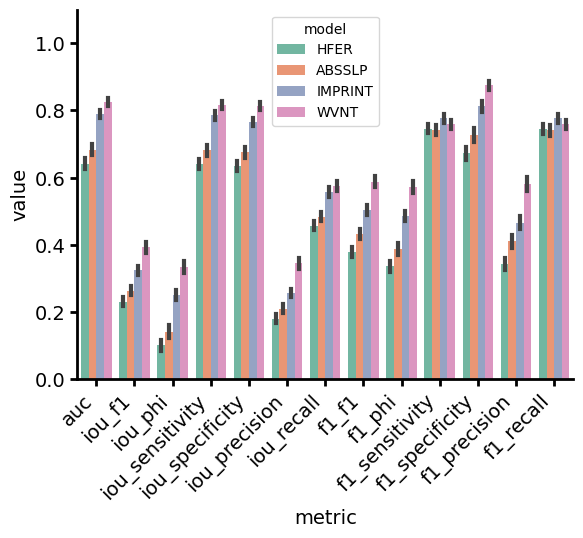

In [40]:
# sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette=['purple','blue','green','red'],hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])

# sns.stripplot(x='metric',y='value',hue='model',data=shallow_melted, dodge=True, jitter=True,alpha=0.1,color='gray',size=3,legend=False)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
sns.despine()

In [41]:
# sns.barplot(x='model',y='threshold',data=shallow_data,palette=['blue','green','red'])
# sns.stripplot(x='model',y='threshold',data=shallow_data, dodge=True, jitter=True,alpha=0.1,color='gray',size=3)
# sns.despine()
iou_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'iou_threshold':'mean'}).reset_index().groupby('model').agg({'iou_threshold':'mean'}).reset_index()
f1_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'f1_threshold':'mean'}).reset_index().groupby('model').agg({'f1_threshold':'mean'}).reset_index()

print(iou_benchmark_thresholds)
print(f1_benchmark_thresholds)

     model  iou_threshold
0   ABSSLP     273.018585
1     HFER      46.724448
2  IMPRINT      16.311512
3     WVNT       0.418830
     model  f1_threshold
0   ABSSLP    290.791505
1     HFER     50.379149
2  IMPRINT     19.640619
3     WVNT      0.464512


In [48]:
shallow_data[(shallow_data.patient == 'HUP225') & (shallow_data.model == 'WVNT')]

,patient,onset,model,auc,iou_threshold,iou_f1,iou_phi,iou_sensitivity,iou_specificity,iou_precision,iou_recall,f1_threshold,f1_f1,f1_phi,f1_sensitivity,f1_specificity,f1_precision,f1_recall
2922,HUP225,403854,WVNT,0.505176,0.109608,0.061224,-0.092714,0.571429,0.362319,0.032967,0.428571,0.403610,0.117647,0.065676,0.142857,0.934783,0.100000,0.142857
2926,HUP225,604806,WVNT,0.408451,0.110590,0.039216,-0.102928,0.400000,0.323944,0.020619,0.400000,0.182507,0.076923,0.032298,0.400000,0.683099,0.042553,0.400000
2930,HUP225,598273,WVNT,0.189209,0.095377,0.017544,-0.246266,0.200000,0.215827,0.009174,0.200000,0.079260,0.059701,-0.059500,0.800000,0.100719,0.031008,0.800000
2934,HUP225,311037,WVNT,0.313889,0.074081,0.017857,-0.214588,0.400000,0.263889,0.009346,0.200000,0.314288,0.285714,0.302117,0.200000,0.993056,0.500000,0.200000
2938,HUP225,309947,WVNT,0.713294,0.153259,0.150943,0.127804,0.714286,0.708333,0.086957,0.571429,0.151467,0.185185,0.191917,0.714286,0.708333,0.106383,0.714286
2942,HUP225,304819,WVNT,0.473016,0.177140,0.076923,-0.032530,0.428571,0.488889,0.042254,0.428571,0.494882,0.200000,0.192753,0.142857,0.985185,0.333333,0.142857
2946,HUP225,312474,WVNT,0.494581,0.177025,0.071429,-0.034282,0.428571,0.482759,0.038961,0.428571,0.931529,0.444444,0.525538,0.285714,1.000000,1.000000,0.285714


<Axes: ylabel='iou_threshold'>

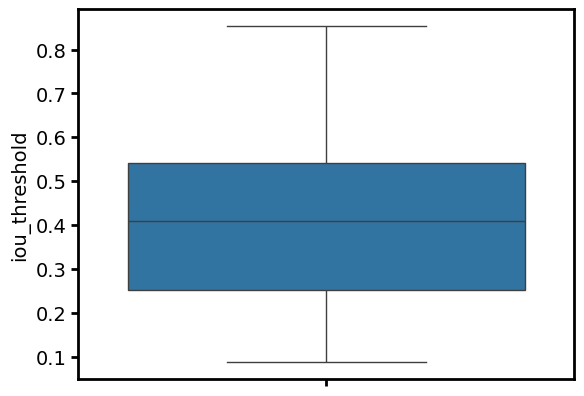

In [45]:
sns.boxplot(shallow_data[shallow_data.model == 'WVNT'].groupby(['model','patient']).agg({'iou_threshold':'mean'}).reset_index()['iou_threshold'])

In [117]:
f1_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_f1.csv'))
iou_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_iou.csv'))

## Generalized Validation performance

In [14]:
val_data = pd.read_csv(ospj(prodatapath, "benchmark_val_analysis_results_f1.csv"))


In [16]:
val_data.onset.nunique()

1030

In [145]:
val_data_onset = val_data.melt(id_vars=['patient','model'], value_vars=['sensitivity','specificity','f1','phi'], var_name='metric', value_name='value')
val_data_spread = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_spread_rank_pct','avg_soz_spread_rank_pct'], var_name='metric', value_name='value')
val_data_latency = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_recruitment_latency','avg_soz_recruitment_latency'], var_name='metric', value_name='value')

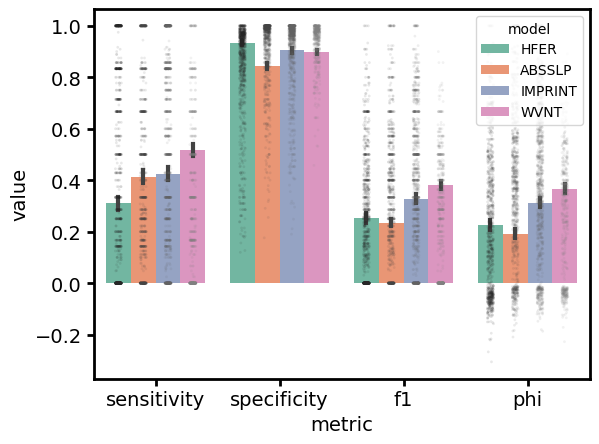

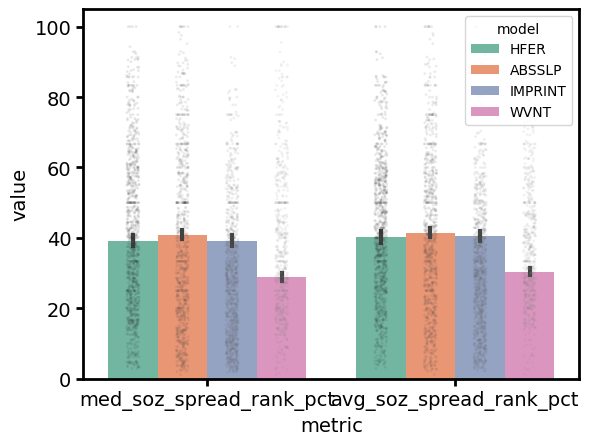

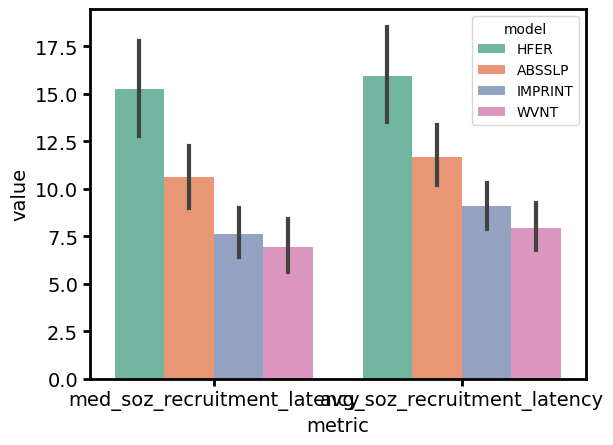

In [146]:
sns.barplot(x='metric',y='value',hue='model',data=val_data_onset,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_onset,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_spread,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_spread,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_latency,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
# sns.stripplot(x='metric',y='value',hue='model',data=val_data_latency,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

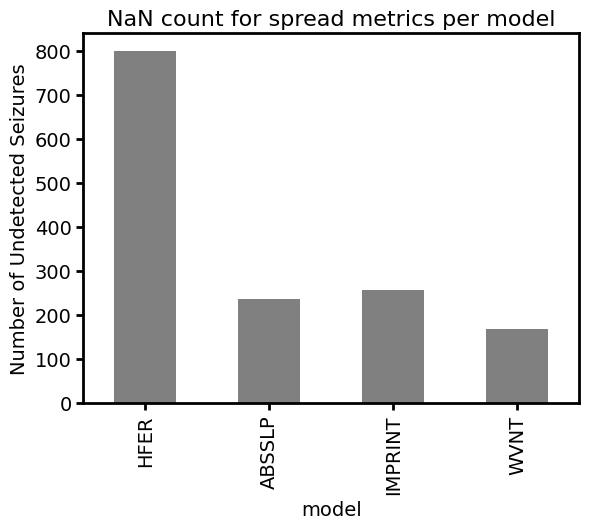

In [99]:
spread_nan_counts = val_data_spread[val_data_spread['value'].isna()].groupby('model').size()
spread_nan_counts = spread_nan_counts.reindex(['HFER','ABSSLP','IMPRINT','WVNT']).fillna(0)
spread_nan_counts.plot(kind='bar',color='gray')
plt.ylabel('Number of Undetected Seizures')
plt.title('NaN count for spread metrics per model')
plt.show()
